# Mean Forecast: Service-Level Probability

This notebook treats the safety-stock target as a **cycle service level probability**
(e.g. 0.95 = 95% of cycles have no stockout), converting it to a z-factor via
`replenishment.math_.normal_quantile` and feeding that z into `SqrtHorizonSafetyStock`.

**Scope note (rewritten against the new strategy-composed API, Task 14):**
janrth's original notebook optimized many articles at once via batch helpers
(`optimize_service_level_factors`/`simulate_replenishment_for_articles`/
`optimize_aggregation_and_service_level_factors`) that were never ported into this repo
(see `io_.py`'s module docstring: the aggregation-window and batch-simulation ecosystem
is out of scope for Tasks 1-13). This rewrite uses `ReplenishmentPolicy`,
`calibration.optimize`, and `simulate_replenishment` directly, looping per article where
the original looped implicitly inside the batch helper. Article counts are reduced from
the original notebook to keep demo runtime reasonable.

In [1]:
from dataclasses import replace
import random

import pandas as pd

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.math_ import normal_quantile
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters

In [2]:
review_period = 1
forecast_horizon = 1

## 1) Generate Sample Data

In [3]:
history_mean = 20.0
history_std = 8.0
forecast_mean = 18.0
forecast_std = 6.0

rows = generate_standard_simulation_rows(
    n_unique_ids=10,
    periods=90,
    history_mean=history_mean,
    history_std=history_std,
    forecast_mean=forecast_mean,
    forecast_std=forecast_std,
    forecast_start_period=60,
    lead_time=3,
    initial_on_hand=25,
    current_stock=25,
    holding_cost_per_unit=1,
    stockout_cost_per_unit=8,
    order_cost_per_order=10,
    seed=7,
)
backtest_rows, evaluation_rows = split_standard_simulation_rows(rows)

rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

evaluation_rows = [
    replace(row, actuals=_sample_int(history_mean, history_std), demand=_sample_int(history_mean, history_std))
    for row in evaluation_rows
]

rows_df = standard_simulation_rows_to_dataframe(backtest_rows + evaluation_rows, library="pandas")
print(f"backtest rows: {len(backtest_rows)}, forecast rows: {len(evaluation_rows)}")

candidate_service_levels = [.50, .70, .80, .85, .90, .95, .97, .99]

backtest rows: 600, forecast rows: 300


## 2) Optimize the cycle service-level probability per article
`normal_quantile(p)` converts each candidate probability to a z-factor; `SqrtHorizonSafetyStock(factor=z)` then applies it. `calibration.optimize` scores each candidate on a held-out validation slice.

In [4]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

In [5]:
backtest_by_article = _group_by_article(backtest_rows)
forecast_by_article = _group_by_article(evaluation_rows)

decision_rows = []
calibration_results = {}
for unique_id, article_backtest in backtest_by_article.items():
    demand = [r.demand for r in article_backtest]
    actuals = [r.actuals for r in article_backtest]
    forecast_values = [r.forecast for r in article_backtest]
    lead_time = article_backtest[0].lead_time

    def candidate_builder(service_level, forecast_values=forecast_values, actuals=actuals, lead_time=lead_time):
        z = normal_quantile(service_level)
        return ReplenishmentPolicy.order_up_to(
            forecast=TimeSeries.from_values(forecast_values),
            actuals=TimeSeries.from_values(actuals),
            safety_stock=SqrtHorizonSafetyStock(factor=z),
            lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
        )

    result = optimize(
        candidate_builder=candidate_builder, candidate_values=candidate_service_levels,
        periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
        lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
        order_cost_per_order=article_backtest[0].order_cost_per_order,
    )
    calibration_results[unique_id] = result

    article_forecast_rows = forecast_by_article.get(unique_id, [])
    if not article_forecast_rows:
        continue
    eval_policy = candidate_builder(
        result.best_value, forecast_values=[r.forecast for r in article_forecast_rows], actuals=actuals,
    )
    current_stock = article_forecast_rows[0].current_stock
    simulation = simulate_replenishment(
        periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
        initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
        holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
        order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
    )
    for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
        decision_rows.append(ReplenishmentDecisionRow(
            unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
            demand=snapshot.demand, incoming_stock=snapshot.received,
            starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
            on_order=snapshot.on_order, backorders=snapshot.backorders,
            sigma=result.best_value, service_level_mode="service_level",
        ))

calibration_summary_df = pd.DataFrame([
    {"unique_id": uid, "calibrated_service_level": result.best_value, "validation_cost": result.best_validation_cost}
    for uid, result in calibration_results.items()
])
decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
calibration_summary_df

,unique_id,calibrated_service_level,validation_cost
0,A,0.99,1156.0
1,B,0.99,979.0
2,C,0.99,1302.0
3,D,0.99,1358.0
4,E,0.99,954.0
5,F,0.97,834.0
6,G,0.99,1018.0
7,H,0.99,1088.0
8,I,0.99,856.0
9,J,0.99,1073.0


### Plot

<Axes: title={'center': 'Service-level calibrated decisions (aggregate)'}, xlabel='Date', ylabel='Units'>

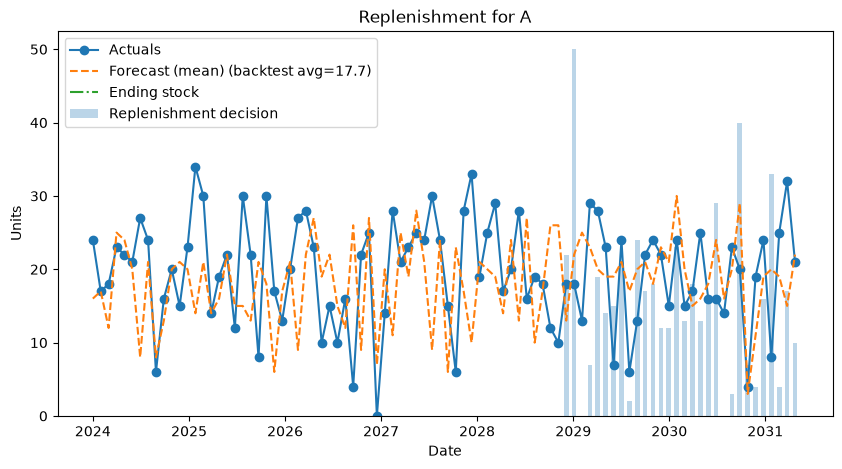

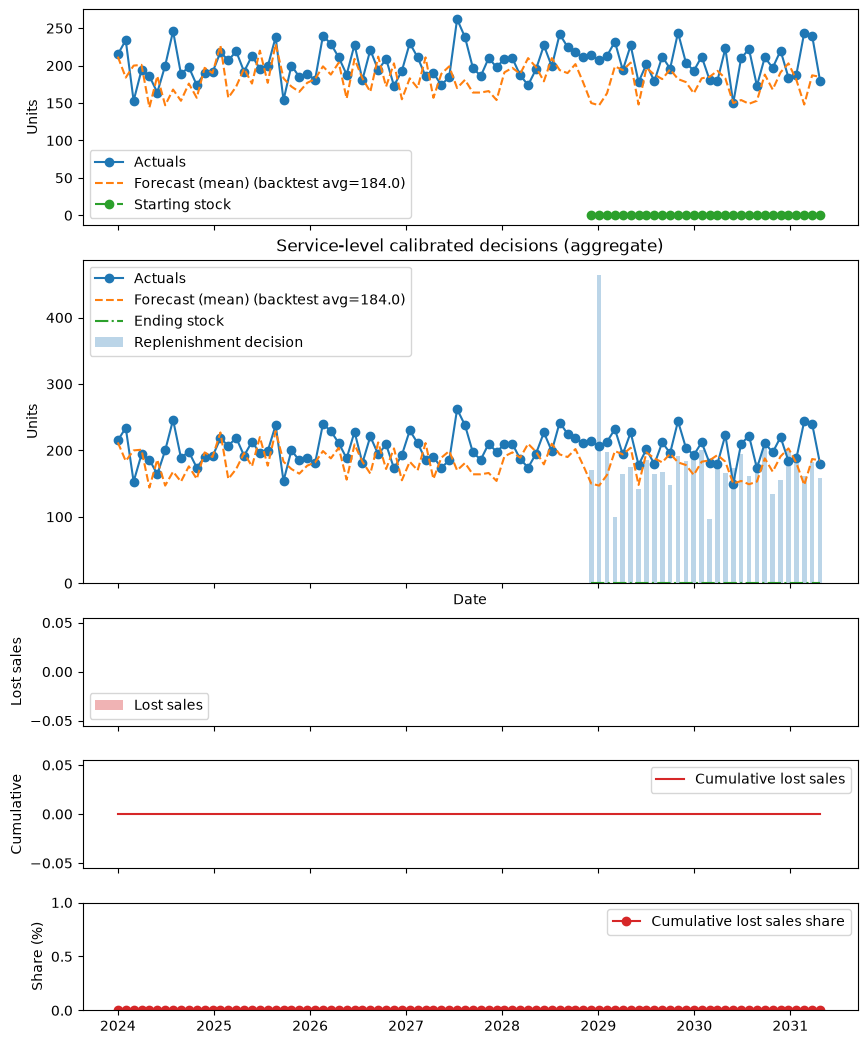

In [6]:
example_id = decisions_df["unique_id"].iloc[0]
plot_replenishment_decisions(rows_df, decisions_df, unique_id=example_id)
plot_replenishment_decisions(rows_df, decisions_df, aggregate=True, title="Service-level calibrated decisions (aggregate)")

## 3) Review period + forecast horizon

`review_period` sets the order cadence (every N periods); `forecast_horizon` sets the
coverage window excluding lead time. The policy's total protection horizon is
`lead_time + forecast_horizon`. We can brute-force sweep `forecast_horizon` the same way
we swept the service level above, reusing `calibration.optimize` for each candidate
horizon and picking the one with the lowest total validation cost across articles.

In [7]:
candidate_horizons = [1, 2, 3, 5, 7]
horizon_costs = {}
for horizon in candidate_horizons:
    total_cost = 0.0
    for unique_id, article_backtest in backtest_by_article.items():
        demand = [r.demand for r in article_backtest]
        actuals = [r.actuals for r in article_backtest]
        forecast_values = [r.forecast for r in article_backtest]
        lead_time = article_backtest[0].lead_time

        def candidate_builder(service_level, forecast_values=forecast_values, actuals=actuals,
                               lead_time=lead_time, horizon=horizon):
            z = normal_quantile(service_level)
            return ReplenishmentPolicy.order_up_to(
                forecast=TimeSeries.from_values(forecast_values),
                actuals=TimeSeries.from_values(actuals),
                safety_stock=SqrtHorizonSafetyStock(factor=z),
                lead_time=lead_time, review_period=review_period, forecast_horizon=horizon,
            )

        result = optimize(
            candidate_builder=candidate_builder, candidate_values=candidate_service_levels,
            periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
            lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
            stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
            order_cost_per_order=article_backtest[0].order_cost_per_order,
        )
        total_cost += result.best_validation_cost
    horizon_costs[horizon] = total_cost

best_horizon = min(horizon_costs, key=horizon_costs.get)
horizon_costs, best_horizon

({1: 10618.0, 2: 9060.0, 3: 9284.0, 5: 10515.0, 7: 13550.0}, 2)